In [9]:
import numpy as np
import matplotlib.pylab as plt
import time
import math

from mgdraw_output_reader_NOVO_v03 import DetectionDataStorage

primaries_per_spawn = 1.0e7
number_of_files = 100
number_of_primaries = primaries_per_spawn * number_of_files

beam_current = 2.0 # nA

Script will make Figure 3 in manuscript 1. 

Assumes that gamma_hits.txt and neutron_hits.txt files have been made beforehand

Script will build triple coincidence gamma events and double coincidence neutron events and plot these for each patient

Flow:
    - Build events per spot per patient
    - Save the number of events in a numpy array
    - Plot

In [10]:
def load_hits(main_PATH):

    from hit_txt_file_reader_v01 import collect_txt_data

    files = {"spot1": None, "spot2": None, "spot3": None, "spot4": None, "spot5": None,
            "spot6": None, "spot7": None, "spot8": None, "spot9": None, "spot10": None}

    m = 0
    for file in files:
        m += 1

        newPath = main_PATH + rf"\Results_spot_{m}"
        print(f"Spot {m}:")

        # Importing gamma_hits
        print("Gamma hits")
        gamma_hits = np.array(collect_txt_data(newPath + rf"\gamma_hits.txt"))

        # Importing neutron_hits
        print("Neutron hits")
        neutron_hits = np.array(collect_txt_data(newPath + rf"\neutron_hits.txt"))

        files[file] = [gamma_hits, neutron_hits]

    return files

Building triple coincident gamma events and double coincident neutron events

In [11]:
# Taken from DetectionDataStorage from mgdraw_output_reader_NOVO_v03.py
def event_builder(gamma_hits, neutron_hits):
    """
    Will sort self.gamma_hits() and self.neutron_hits() to construct:
    1) self.gamma_events() and self.neutron_events() 

        structure: np.array([
        [[hit1], [hit2], [hit3]],
        [[hit1]],
        [[hit1], [hit2], [hit3], [hit4]]
        ])
    2) self.double_gamma_events, self.triple_gamma_events, self.double_neutron_events, self.triple_neutron_events

        structure double events: np.array([
        [[hit1], [hit2]],
        [[hit1], [hit2]],
        [[hit1], [hit2]]
        ])

        structure triple events: np.array([
        [[hit1], [hit2], [hit3]],
        [[hit1], [hit2], [hit3]],
        [[hit1], [hit2], [hit3]]
        ])

    Returns the number of gamma events and neutron events with coincidences [[1+, 2+, 3+], [1+ ,2+, 3+]], respectively
    """

    # 1) Construct events from hits
    # Gammas
    gamma_events = _event_builder(gamma_hits)
    print("Event summary for gammas:")
    _count_hits_per_event(gamma_events)

    # Neutrons
    neutron_events = _event_builder(neutron_hits)
    print("Event summary for neutrons:")
    _count_hits_per_event(neutron_events)

    # 2) Filter out double/triple events
    # Sorting out double and triple gamma/neutron events

    # Gammas
    double_gamma_events = [event[0:2] for event in gamma_events if len(event) >= 2]
    triple_gamma_events = [event[0:3] for event in gamma_events if len(event) >= 3]

    # Neutrons
    double_neutron_events = [event[0:2] for event in neutron_events if len(event) >= 2]
    triple_neutron_events = [event[0:3] for event in neutron_events if len(event) >= 3]

    return [
        [len(gamma_events), len(double_gamma_events), len(triple_gamma_events)], 
        [len(neutron_events), len(double_neutron_events), len(triple_neutron_events)]
        ]


def _event_builder(hit_array):
    """
    Helper function for event_builder
    Inputs: hit array, i.e. self.gamma_hits or self.neutron_hits
    Output: event array, self.gamma_events or self.neutron_events
    """

    event = []  #[[hit1], [hit2], [hit3], ..., [hitN]]
    particle_events = []    # [[[hit1], [hit2], [hit3]], [[hit1], [hit2]], ...] # Final event list, i.e. self.gamma_events or self.neutron_events
    event_ID = [0, 0.0, 0.0, 0.0]   # [NCASE, prodX, prodY, prodZ], ID to sort hits into the same event

    for hit in hit_array:
        # A change in event_ID means that there is a new event
        if event_ID != [hit[1], hit[15], hit[16], hit[17]]:

            # Add the event if it is not the beginning event
            if event_ID != [0, 0.0, 0.0, 0.0]:
                particle_events.append(event)

            # Reset event
            event = [hit]
            event_ID = [hit[1], hit[15], hit[16], hit[17]]

        else:
            event.append(hit)

    # Add the final event
    particle_events.append(event)

    return particle_events

def _count_hits_per_event(event_array):
    """
    Helper function for event_builder. Will summarise the number of hits in events
    Input: event array, i.e. self.gamma_events or self.neutron_events
    Output: print statements about number of hits per event and their counts, i.e. 1 hit : 50203, 2 hits : 4120, 3 hits : 120
    """

    # Collect the number of hits per event
    event_chain = []
    for event in event_array:
        event_chain.append(len(event))

    # Convert to numpy and counting how many events with 1 hit, 2 hits, 3 hits etc.
    event_chain = np.array(event_chain)
    chain_lengths, chain_lengths_counts = np.unique(event_chain, return_counts=True)

    for chain_length, chain_length_count in zip(chain_lengths, chain_lengths_counts):
        if chain_length == 1:
            print(f" {chain_length} hit : {chain_length_count}")
        else:
            print(f" {chain_length} hits : {chain_length_count}")

In [ ]:
def load_and_build_events(PATH):

    files = load_hits(PATH)

    num_triple_gammas = []
    num_double_neutrons = []

    num_double_gammas = []
    num_triple_neutrons = []

    for spot in files:
        gamma_hits = np.transpose(files[spot][0])
        neutron_hits = np.transpose(files[spot][1])
        num_gamma_events, num_neutron_events = event_builder(gamma_hits, neutron_hits)

        num_triple_gammas.append(num_gamma_events[2])
        num_double_neutrons.append(num_neutron_events[1])

    return num_triple_gammas, num_double_neutrons

In [ ]:
# Container of number of 2FNs and 3PGs
triple_gamma_events = {"brain": [], "HNC": [], "lung": [], "prostate": []}
double_neutron_events = {"brain": [], "HNC": [], "lung": [], "prostate": []}

double_gamma_events = {"brain": [], "HNC": [], "lung": [], "prostate": []}
triple_neutron_events = {"brain": [], "HNC": [], "lung": [], "prostate": []}


# Pediatric brain
brain_energies = [120.239, 112.948, 109.551, 106.152, 99.65, 93.544, 87.635, 82.123, 76.909, 71.993]
brain_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Brain_Hv14\270_degree"
triple_gamma_events["brain"], double_neutron_events["brain"] = load_and_build_events(brain_PATH)


# HNC
HNC_energies = [134.006, 126.327, 119.041, 111.849, 105.052, 98.649, 92.643, 86.733, 81.321, 76.106]
HNC_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_HNC_05\AntObl_L_G80"
triple_gamma_events["HNC"], double_neutron_events["HNC"] = load_and_build_events(HNC_PATH)


# Lung
lung_energies = [180.740, 169.121, 158.789, 149.843, 140.982, 132.012, 123.633, 115.546, 108.051, 100.751]
lung_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Lung_04\Beam_1"
triple_gamma_events["lung"], double_neutron_events["lung"] = load_and_build_events(lung_PATH)


# Prostate
prostate_energies = [198, 195, 192, 189, 186, 183, 180, 177, 174, 171]
prostate_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Prostate_01_2field\270"
triple_gamma_events["prostate"], double_neutron_events["prostate"] = load_and_build_events(prostate_PATH)

Spot 1:
Gamma hits
Neutron hits
Spot 2:
Gamma hits
Neutron hits
Spot 3:
Gamma hits
Neutron hits
Spot 4:
Gamma hits
Neutron hits
Spot 5:
Gamma hits
Neutron hits
Spot 6:
Gamma hits
Neutron hits
Spot 7:
Gamma hits
Neutron hits
Spot 8:
Gamma hits
Neutron hits
Spot 9:
Gamma hits
Neutron hits
Spot 10:
Gamma hits
Neutron hits
Event summary for gammas:
 1 hit : 294933
 2 hits : 37040
 3 hits : 4883
 4 hits : 699
 5 hits : 73
 6 hits : 5
 7 hits : 3
Event summary for neutrons:
 1 hit : 137021
 2 hits : 16245
 3 hits : 1375
 4 hits : 84
 5 hits : 2
Event summary for gammas:
 1 hit : 267979
 2 hits : 33602
 3 hits : 4510
 4 hits : 651
 5 hits : 63
 6 hits : 6
 7 hits : 1
Event summary for neutrons:
 1 hit : 124193
 2 hits : 15008
 3 hits : 1280
 4 hits : 77
 5 hits : 4
 6 hits : 1
Event summary for gammas:
 1 hit : 253569
 2 hits : 31680
 3 hits : 4251
 4 hits : 574
 5 hits : 75
 6 hits : 9
Event summary for neutrons:
 1 hit : 117115
 2 hits : 14296
 3 hits : 1281
 4 hits : 78
Event summary for g

In [ ]:
print(triple_gamma_events)
print(double_neutron_events)

ratios = {"brain": [], "HNC": [], "lung": [], "prostate": []}

for name in ratios:
    ratios[name] = np.array(double_neutron_events[name]) / np.array(triple_gamma_events[name])

print(ratios)
for ratio in ratios:
    print("----")
    print(round(np.average(ratios[ratio]), 4))
    print(round(np.std(ratios[ratio]), 4))
    print(round(sum(ratios[ratio]) / 10, 3))
    

{'brain': [5663, 5231, 4909, 4793, 4287, 3961, 3531, 3334, 2926, 2674], 'HNC': [10630, 9647, 8594, 7590, 6768, 6117, 5559, 4950, 4471, 3970], 'lung': [5341, 4808, 4424, 3973, 3517, 3158, 2737, 2544, 2237, 1965], 'prostate': [7599, 7294, 6807, 6708, 6504, 6216, 5984, 5694, 5528, 5344]}
{'brain': [17706, 16370, 15655, 14928, 13608, 12219, 11063, 9964, 8955, 7924], 'HNC': [42217, 39739, 36687, 33734, 30396, 27753, 25193, 22471, 20121, 17716], 'lung': [14536, 13671, 12901, 11698, 10629, 9503, 8642, 7690, 6781, 6243], 'prostate': [18291, 18040, 17622, 17293, 17006, 16522, 16394, 15895, 15736, 15247]}
{'brain': array([3.12661134, 3.12942076, 3.18904054, 3.11454204, 3.17424773,
       3.08482706, 3.13310677, 2.98860228, 3.06049214, 2.96335079]), 'HNC': array([3.97149577, 4.1193117 , 4.26890854, 4.44453228, 4.49113475,
       4.53702795, 4.5319302 , 4.53959596, 4.5003355 , 4.46246851]), 'lung': array([2.72158772, 2.84338602, 2.91613924, 2.94437453, 3.02217799,
       3.00918303, 3.15747168, 3.

In [ ]:
print(max(triple_gamma_events["HNC"]) / 1e9)
print(max(double_neutron_events["HNC"]) / 1e9)

print(min(triple_gamma_events["lung"]) / 1e9)
print(min(double_neutron_events["lung"]) / 1e9)

1.063e-05
4.2217e-05
1.965e-06
6.243e-06


Plotting

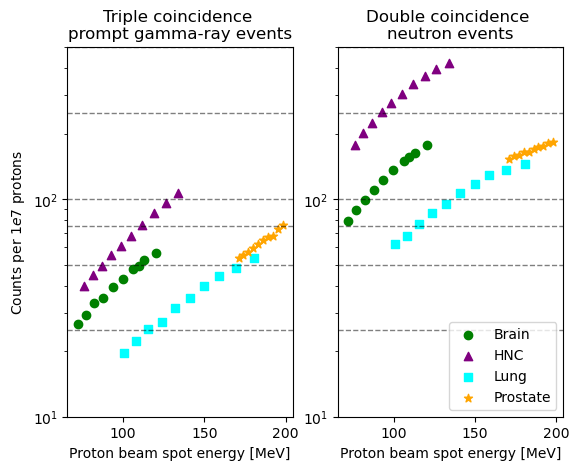

In [17]:
from matplotlib.ticker import FuncFormatter

def log_formatter(y, _):
    power = np.log10(y / 1e2)
    return rf'$10^{{{int(power)}}}$'


# Gamma data
plt.subplot(1, 2, 1)

# Triple gamma counts
plt.scatter(brain_energies, triple_gamma_events["brain"], marker="o", color="green", label="Ped. brain")
plt.scatter(HNC_energies, triple_gamma_events["HNC"], marker="^", color="purple", label="HNC")
plt.scatter(lung_energies, triple_gamma_events["lung"], marker="s", color="cyan", label="Lung")
plt.scatter(prostate_energies, triple_gamma_events["prostate"], marker="*", color="orange", label="Prostate")

# Axes control
plt.yscale("log")
plt.ylim([1e3, 5e4])

# Horizontal visualization lines
for i in range(1, 5):
    plt.axhline(y=i * 2.5e3, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

for i in range(1, 5):
    plt.axhline(y=i * 2.5e4, linestyle="--", color="black", linewidth=1.0, alpha=0.5)


plt.title("Triple coincidence \nprompt gamma-ray events")
plt.xlabel("Proton beam spot energy [MeV]")
#plt.ylabel("Counts")
plt.ylabel("Counts per $1e7$ protons")
#plt.legend()

ax = plt.gca()
ax.set_yscale("log")

ax.yaxis.set_major_formatter(
    FuncFormatter(log_formatter)
)


# Neutron data
plt.subplot(1, 2, 2)

plt.scatter(brain_energies, double_neutron_events["brain"], marker="o", color="green", label="Brain")
plt.scatter(HNC_energies, double_neutron_events["HNC"], marker="^", color="purple", label="HNC")
plt.scatter(lung_energies, double_neutron_events["lung"], marker="s", color="cyan", label="Lung")
plt.scatter(prostate_energies, double_neutron_events["prostate"], marker="*", color="orange", label="Prostate")

plt.yscale("log")
#plt.yticks([1e-6, 1e-5, 1e-4], "")
#plt.ylim([1e-6, 1e-4])
plt.yticks()
plt.ylim([1e3, 5e4])

for i in range(1, 5):
    plt.axhline(y=i * 2.5e3, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

for i in range(1, 5):
    plt.axhline(y=i * 2.5e4, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

plt.minorticks_on

plt.title("Double coincidence \nneutron events")
plt.xlabel("Proton beam spot energy [MeV]")
#plt.ylabel("Counts")
plt.legend(loc="lower right")

ax = plt.gca()
ax.set_yscale("log")

ax.yaxis.set_major_formatter(
    FuncFormatter(log_formatter)
)

Testing how many events are los when going from double gammas to triple gammas

In [ ]:
brain_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Brain_Hv14\270_degree"


test = DetectionDataStorage(brain_PATH + r"\Results_spot_1\scintillator_interactions", primaries_per_spawn=1e7, max_files=100, detector="NOVCoDA")
test.load_data(mgdraw_version_8_plus=False)

Reading 105 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data collection: 36.13 s


In [20]:
test.filter_hits()
test.event_builder()


-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 31.76 s
Total number of lines: 3459183
Number of lines kept: 920661 (26.6%)
Number of lines rejected: 2538522 (73.4%)

-----------HIT MERGING-----------
Merging complete. Time used: 15.05 s
Overlaps found: 128067
Total number of hit histories > 10/200 keV: 561167
Number of gamma hit histories > 10 keV: 386874
Number of neutron hit histories > 200 keV: 173982
Number of combo hit histories > 200 keV: 311
Event summary for gammas:
 1 hit : 294933
 2 hits : 37040
 3 hits : 4883
 4 hits : 699
 5 hits : 73
 6 hits : 5
 7 hits : 3
Event summary for neutrons:
 1 hit : 137021
 2 hits : 16245
 3 hits : 1375
 4 hits : 84
 5 hits : 2


In [ ]:

print(len(test.double_gamma_events))
print(len(test.triple_gamma_events))

print(len(test.double_neutron_events))
print(len(test.triple_neutron_events))

42703
5663
17706
1461


WARNING: TAKES ~100 min to run!! Use pickled data below

In [ ]:
# Container of number of 2/3FNs and 2/3PGs
coincidence_events = {"brain": [], "HNC": [], "lung": [], "prostate": []}

# Pediatric brain
brain_energies = [120.239, 112.948, 109.551, 106.152, 99.65, 93.544, 87.635, 82.123, 76.909, 71.993]
brain_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Brain_Hv14\270_degree"
for i in range(1, 11):
    data = DetectionDataStorage(brain_PATH + rf"\Results_spot_{i}\scintillator_interactions")
    data.load_data(mgdraw_version_8_plus=False)
    data.filter_hits()
    data.event_builder()
    num_events = [len(data.double_gamma_events), len(data.triple_gamma_events), len(data.double_neutron_events), len(data.triple_neutron_events)]
    coincidence_events["brain"].append(num_events)


# HNC
HNC_energies = [134.006, 126.327, 119.041, 111.849, 105.052, 98.649, 92.643, 86.733, 81.321, 76.106]
HNC_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_HNC_05\AntObl_L_G80"
for i in range(1, 11):
    data = DetectionDataStorage(HNC_PATH + rf"\Results_spot_{i}\scintillator_interactions")
    data.load_data(mgdraw_version_8_plus=False)
    data.filter_hits()
    data.event_builder()
    num_events = [len(data.double_gamma_events), len(data.triple_gamma_events), len(data.double_neutron_events), len(data.triple_neutron_events)]
    coincidence_events["HNC"].append(num_events)


# Lung
lung_energies = [180.740, 169.121, 158.789, 149.843, 140.982, 132.012, 123.633, 115.546, 108.051, 100.751]
lung_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Lung_04\Beam_1"
for i in range(1, 11):
    data = DetectionDataStorage(lung_PATH + rf"\Results_spot_{i}\scintillator_interactions")
    data.load_data(mgdraw_version_8_plus=False)
    data.filter_hits()
    data.event_builder()
    num_events = [len(data.double_gamma_events), len(data.triple_gamma_events), len(data.double_neutron_events), len(data.triple_neutron_events)]
    coincidence_events["lung"].append(num_events)


# Prostate
prostate_energies = [198, 195, 192, 189, 186, 183, 180, 177, 174, 171]
prostate_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Prostate_01_2field\270"
for i in range(1, 11):
    data = DetectionDataStorage(prostate_PATH + rf"\Results_spot_{i}\scintillator_interactions")
    data.load_data(mgdraw_version_8_plus=False)
    data.filter_hits()
    data.event_builder()
    num_events = [len(data.double_gamma_events), len(data.triple_gamma_events), len(data.double_neutron_events), len(data.triple_neutron_events)]
    coincidence_events["prostate"].append(num_events)

Reading 105 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data collection: 52.01 s

-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 64.69 s
Total number of lines: 3459183
Number of lines kept: 920661 (26.6%)
Number of lines rejected: 2538522 (73.4%)

-----------HIT MERGING-----------
Merging complete. Time used: 29.54 s
Overlaps found: 128067
Total number of hit histories > 10/200 keV: 561167
Number of gamma hit histories > 10 keV: 386874
Number of neutron hit histories > 200 keV: 173982
Number of combo hit histories > 200 keV: 311
Event summary for gammas:
 1 hit : 294933
 2 hits : 37040
 3 hits : 4883
 4 hits : 699
 5 hits : 73
 6 hits : 5
 7 hits : 3
Event summary for neutrons:
 1 hit : 137021
 2 hits : 16245
 3 hits : 1375
 4 hits : 84
 5 hits : 2
Reading 102 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data collection: 43.04 s

-

In [ ]:
brain_data = np.array(coincidence_events["brain"])
HNC_data = np.array(coincidence_events["HNC"])
lung_data = np.array(coincidence_events["lung"])
prostate_data = np.array(coincidence_events["prostate"])

print(brain_data[:, 0])

[42703 38833 36589 35515 32246 29367 26713 23876 21473 19658]
[42703  5663 17706  1461]


Saving data as .pickle

In [52]:
import pickle

# Brain
with open(brain_PATH + r"\brain_coinc_events.pkl", "wb") as burner_file:
    pickle.dump(brain_data, burner_file)
    burner_file.close()

# HNC
with open(HNC_PATH + r"\HNC_coinc_events.pkl", "wb") as burner_file:
    pickle.dump(HNC_data, burner_file)
    burner_file.close()

# Lung
with open(lung_PATH + r"\lung_coinc_events.pkl", "wb") as burner_file:
    pickle.dump(lung_data, burner_file)
    burner_file.close()

# Prostate
with open(prostate_PATH + r"\prostate_coinc_events.pkl", "wb") as burner_file:
    pickle.dump(prostate_data, burner_file)
    burner_file.close()

In [53]:
# Importing pickle data

# Brain
with open(brain_PATH + r"\brain_coinc_events.pkl", "rb") as burner_file:
    maybe_brain_data = pickle.load(burner_file)
    burner_file.close()

print(maybe_brain_data)

[[42703  5663 17706  1461]
 [38833  5231 16370  1362]
 [36589  4909 15655  1359]
 [35515  4793 14928  1297]
 [32246  4287 13608  1186]
 [29367  3961 12219  1091]
 [26713  3531 11063   893]
 [23876  3334  9964   876]
 [21473  2926  8955   786]
 [19658  2674  7924   690]]


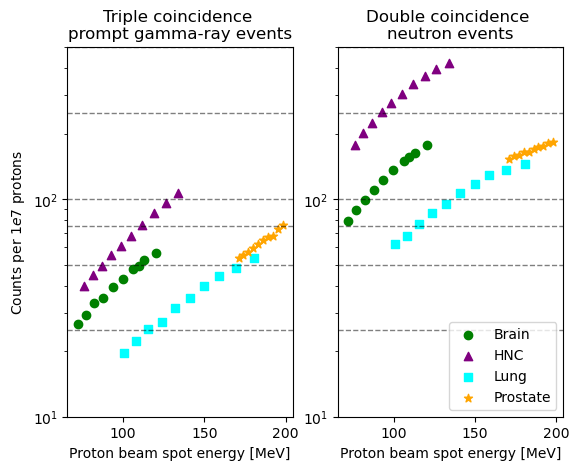

In [33]:
from matplotlib.ticker import FuncFormatter

def log_formatter(y, _):
    power = np.log10(y / 1e2)
    return rf'$10^{{{int(power)}}}$'


# Gamma data
plt.subplot(1, 2, 1)

# Triple gamma counts
plt.scatter(brain_energies, brain_data[:, 1], marker="o", color="green", label="Ped. brain")
plt.scatter(HNC_energies, HNC_data[:, 1], marker="^", color="purple", label="HNC")
plt.scatter(lung_energies, lung_data[:, 1], marker="s", color="cyan", label="Lung")
plt.scatter(prostate_energies, prostate_data[:, 1], marker="*", color="orange", label="Prostate")

# Axes control
plt.yscale("log")
plt.ylim([1e3, 5e4])

# Horizontal visualization lines
for i in range(1, 5):
    plt.axhline(y=i * 2.5e3, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

for i in range(1, 5):
    plt.axhline(y=i * 2.5e4, linestyle="--", color="black", linewidth=1.0, alpha=0.5)


plt.title("Triple coincidence \nprompt gamma-ray events")
plt.xlabel("Proton beam spot energy [MeV]")
#plt.ylabel("Counts")
plt.ylabel("Counts per $1e7$ protons")
#plt.legend()

ax = plt.gca()
ax.set_yscale("log")

ax.yaxis.set_major_formatter(
    FuncFormatter(log_formatter)
)


# Neutron data
plt.subplot(1, 2, 2)

plt.scatter(brain_energies, brain_data[:, 2], marker="o", color="green", label="Brain")
plt.scatter(HNC_energies, HNC_data[:, 2], marker="^", color="purple", label="HNC")
plt.scatter(lung_energies, lung_data[:, 2], marker="s", color="cyan", label="Lung")
plt.scatter(prostate_energies, prostate_data[:, 2], marker="*", color="orange", label="Prostate")

plt.yscale("log")
#plt.yticks([1e-6, 1e-5, 1e-4], "")
#plt.ylim([1e-6, 1e-4])
plt.yticks()
plt.ylim([1e3, 5e4])

for i in range(1, 5):
    plt.axhline(y=i * 2.5e3, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

for i in range(1, 5):
    plt.axhline(y=i * 2.5e4, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

plt.minorticks_on

plt.title("Double coincidence \nneutron events")
plt.xlabel("Proton beam spot energy [MeV]")
#plt.ylabel("Counts")
plt.legend(loc="lower right")

ax = plt.gca()
ax.set_yscale("log")

ax.yaxis.set_major_formatter(
    FuncFormatter(log_formatter)
)

Span of 2PGs:(1.4621e-05 - 7.7981e-05) per primary
Span of 3PGs: (0.0 - 0.0) per primary
Span of 2FNs: (0.0 - 0.0) per primary


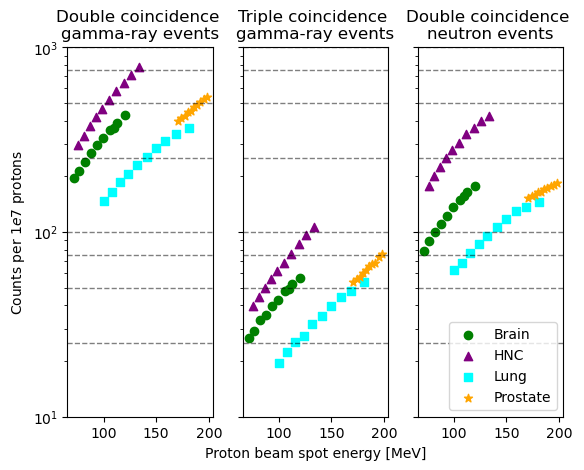

In [ ]:
from matplotlib.ticker import FuncFormatter

def log_formatter(y, _):
    power = np.log10(y / 1e2)
    return rf'$10^{{{int(power)}}}$'

# Double gamma plot
plt.subplot(1, 3, 1)

# Double gamma counts
plt.scatter(brain_energies, brain_data[:, 0], marker="o", color="green", label="Ped. brain")
plt.scatter(HNC_energies, HNC_data[:, 0], marker="^", color="purple", label="HNC")
plt.scatter(lung_energies, lung_data[:, 0], marker="s", color="cyan", label="Lung")
plt.scatter(prostate_energies, prostate_data[:, 0], marker="*", color="orange", label="Prostate")

plt.ylabel("Counts per $1e7$ protons")
plt.title("Double coincidence \ngamma-ray events")

plt.ylim([1e3, 1e5])

for i in range(1, 5):
    plt.axhline(y=i * 2.5e3, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

for i in range(1, 5):
    plt.axhline(y=i * 2.5e4, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

ax = plt.gca()
ax.set_yscale("log")

ax.yaxis.set_major_formatter(
    FuncFormatter(log_formatter)
)


# Gamma data
plt.subplot(1, 3, 2)

# Triple gamma counts
plt.scatter(brain_energies, brain_data[:, 1], marker="o", color="green", label="Ped. brain")
plt.scatter(HNC_energies, HNC_data[:, 1], marker="^", color="purple", label="HNC")
plt.scatter(lung_energies, lung_data[:, 1], marker="s", color="cyan", label="Lung")
plt.scatter(prostate_energies, prostate_data[:, 1], marker="*", color="orange", label="Prostate")

# Axes control
plt.yscale("log")
plt.ylim([1e3, 1e5])

# Horizontal visualization lines
for i in range(1, 5):
    plt.axhline(y=i * 2.5e3, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

for i in range(1, 5):
    plt.axhline(y=i * 2.5e4, linestyle="--", color="black", linewidth=1.0, alpha=0.5)


plt.title("Triple coincidence \ngamma-ray events")
plt.xlabel("Proton beam spot energy [MeV]")
#plt.ylabel("Counts")
#plt.legend()
plt.tick_params(axis="y", labelleft=False)

ax = plt.gca()
ax.set_yscale("log")

ax.yaxis.set_major_formatter(
    FuncFormatter(log_formatter)
)


# Neutron data
plt.subplot(1, 3, 3)

plt.scatter(brain_energies, brain_data[:, 2], marker="o", color="green", label="Brain")
plt.scatter(HNC_energies, HNC_data[:, 2], marker="^", color="purple", label="HNC")
plt.scatter(lung_energies, lung_data[:, 2], marker="s", color="cyan", label="Lung")
plt.scatter(prostate_energies, prostate_data[:, 2], marker="*", color="orange", label="Prostate")

plt.yscale("log")
#plt.yticks([1e-6, 1e-5, 1e-4], "")
#plt.ylim([1e-6, 1e-4])
plt.yticks()
plt.tick_params(axis="y", labelleft=False)
plt.ylim([1e3, 1e5])

for i in range(1, 5):
    plt.axhline(y=i * 2.5e3, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

for i in range(1, 5):
    plt.axhline(y=i * 2.5e4, linestyle="--", color="black", linewidth=1.0, alpha=0.5)

plt.minorticks_on

plt.title("Double coincidence \nneutron events")
#plt.xlabel("Proton beam spot energy [MeV]")
#plt.ylabel("Counts")
plt.legend(loc="lower right")

ax = plt.gca()
ax.set_yscale("log")

ax.yaxis.set_major_formatter(
    FuncFormatter(log_formatter)
)

# Max and min values
# Double coincidence gamma-ray events:
min2PG = min(min(brain_data[:, 0]), min(HNC_data[:, 0]), min(lung_data[:, 0]), min(prostate_data[:, 0]))
max2PG = max(max(brain_data[:, 0]), max(HNC_data[:, 0]), max(lung_data[:, 0]), max(prostate_data[:, 0]))
print(f"Span of 2PGs:({min2PG / 1e9} - {max2PG / 1e9}) per primary")

# Triple coincidence gamma-ray events:
min3PG = min(min(brain_data[:, 1]), min(HNC_data[:, 1]), min(lung_data[:, 1]), min(prostate_data[:, 1]))
max3PG = max(max(brain_data[:, 1]), max(HNC_data[:, 1]), max(lung_data[:, 1]), max(prostate_data[:, 1]))
print(f"Span of 3PGs: ({min3PG} - {max3PG}) per primary")

# Double coincidence neutron events:
min2FN = min(min(brain_data[:, 2]), min(HNC_data[:, 2]), min(lung_data[:, 2]), min(prostate_data[:, 2]))
max2FN = max(max(brain_data[:, 2]), max(HNC_data[:, 2]), max(lung_data[:, 2]), max(prostate_data[:, 2]))
print(f"Span of 2FNs: ({min2FN} - {max2FN}) per primary")

In [58]:
# Estimating double gamma to triple gamma ratios:
print("Double gammas versus triple gammas ratio:")

# Brain
brain_ratios = [brain_data[i, 0] / brain_data[i, 1] for i in range(len(brain_data))]
print(f"Brain ratios: \n Mean: {round(np.mean(brain_ratios), 3)}, range: ({round(min(brain_ratios), 3)}, {round(max(brain_ratios), 3)})")

# HNC
HNC_ratios = [HNC_data[i, 0] / HNC_data[i, 1] for i in range(len(HNC_data))]
print(f"HNC ratios: \n Mean: {round(np.mean(HNC_ratios), 3)}, range: ({round(min(HNC_ratios), 3)}, {round(max(HNC_ratios), 3)})")

# Lung
lung_ratios = [lung_data[i, 0] / lung_data[i, 1] for i in range(len(lung_data))]
print(f"Lung ratios: \n Mean: {round(np.mean(lung_ratios), 3)}, range: ({round(min(lung_ratios), 3)}, {round(max(lung_ratios), 3)})")

# Prostate
prostate_ratios = [prostate_data[i, 0] / prostate_data[i, 1] for i in range(len(prostate_data))]
print(f"Prostate ratios: \n Mean: {round(np.mean(prostate_ratios), 3)}, range: ({round(min(prostate_ratios), 3)}, {round(max(prostate_ratios), 3)})")

Double gammas versus triple gammas ratio:
Brain ratios: 
 Mean: 7.418, range: (7.161, 7.565)
HNC ratios: 
 Mean: 7.479, range: (7.315, 7.641)
Lung ratios: 
 Mean: 7.215, range: (6.804, 7.538)
Prostate ratios: 
 Mean: 7.325, range: (7.082, 7.466)


In [ ]:
# Estimating double neutrons to triple gammas ratio:
print("Double neutrons to triple gammas ratio:")

# Brain
brain_ratios = [brain_data[i, 2] / brain_data[i, 1] for i in range(len(brain_data))]
print(f"Brain ratios: \n Mean: {round(np.mean(brain_ratios), 3)}, range: ({round(min(brain_ratios), 3)}, {round(max(brain_ratios), 3)})")

# HNC
HNC_ratios = [HNC_data[i, 2] / HNC_data[i, 1] for i in range(len(HNC_data))]
print(f"HNC ratios: \n Mean: {round(np.mean(HNC_ratios), 3)}, range: ({round(min(HNC_ratios), 3)}, {round(max(HNC_ratios), 3)})")

# Lung
lung_ratios = [lung_data[i, 2] / lung_data[i, 1] for i in range(len(lung_data))]
print(f"Lung ratios: \n Mean: {round(np.mean(lung_ratios), 3)}, range: ({round(min(lung_ratios), 3)}, {round(max(lung_ratios), 3)})")

# Prostate
prostate_ratios = [prostate_data[i, 2] / prostate_data[i, 1] for i in range(len(prostate_data))]
print(f"Prostate ratios: \n Mean: {round(np.mean(prostate_ratios), 3)}, range: ({round(min(prostate_ratios), 3)}, {round(max(prostate_ratios), 3)})")

print(f"\n 2.407: {1/2.407}, 4.54: {1/4.54}")

Double neutrons to triple gammas ratio:
Brain ratios: 
 Mean: 3.096, range: (2.963, 3.189)
HNC ratios: 
 Mean: 4.387, range: (3.971, 4.54)
Lung ratios: 
 Mean: 2.985, range: (2.722, 3.177)
Prostate ratios: 
 Mean: 2.655, range: (2.407, 2.853)

 2.407: 0.4154549231408392, 4.54: 0.22026431718061673
7.272727272727273
6.904761904761905


In [ ]:
# Estimating double gamma to double neutron ratios:
print("Double gammas versus double neutron ratio:")

# Brain
brain_ratios = [brain_data[i, 0] / brain_data[i, 2] for i in range(len(brain_data))]
print(f"Brain ratios: \n Mean: {round(np.mean(brain_ratios), 3)}, range: ({round(min(brain_ratios), 3)}, {round(max(brain_ratios), 3)})")

# HNC
HNC_ratios = [HNC_data[i, 0] / HNC_data[i, 2] for i in range(len(HNC_data))]
print(f"HNC ratios: \n Mean: {round(np.mean(HNC_ratios), 3)}, range: ({round(min(HNC_ratios), 3)}, {round(max(HNC_ratios), 3)})")

# Lung
lung_ratios = [lung_data[i, 0] / lung_data[i, 2] for i in range(len(lung_data))]
print(f"Lung ratios: \n Mean: {round(np.mean(lung_ratios), 3)}, range: ({round(min(lung_ratios), 3)}, {round(max(lung_ratios), 3)})")

# Prostate
prostate_ratios = [prostate_data[i, 0] / prostate_data[i, 2] for i in range(len(prostate_data))]
print(f"Prostate ratios: \n Mean: {round(np.mean(prostate_ratios), 3)}, range: ({round(min(prostate_ratios), 3)}, {round(max(prostate_ratios), 3)})")

Double gammas versus double neutron ratio:
Brain ratios: 
 Mean: 2.396, range: (2.337, 2.481)
HNC ratios: 
 Mean: 1.708, range: (1.645, 1.847)
Lung ratios: 
 Mean: 2.419, range: (2.342, 2.5)
Prostate ratios: 
 Mean: 2.765, range: (2.614, 2.942)


In [61]:
# Estimating double neutrons to triple neutrons ratio:
print("Double neutrons versus triple netrons ratio:")

# Brain
brain_ratios = [brain_data[i, 2] / brain_data[i, 3] for i in range(len(brain_data))]
print(f"Brain ratios: \n Mean: {round(np.mean(brain_ratios), 3)}, range: ({round(min(brain_ratios), 3)}, {round(max(brain_ratios), 3)})")

# HNC
HNC_ratios = [HNC_data[i, 2] / HNC_data[i, 3] for i in range(len(HNC_data))]
print(f"HNC ratios: \n Mean: {round(np.mean(HNC_ratios), 3)}, range: ({round(min(HNC_ratios), 3)}, {round(max(HNC_ratios), 3)})")

# Lung
lung_ratios = [lung_data[i, 2] / lung_data[i, 3] for i in range(len(lung_data))]
print(f"Lung ratios: \n Mean: {round(np.mean(lung_ratios), 3)}, range: ({round(min(lung_ratios), 3)}, {round(max(lung_ratios), 3)})")

# Prostate
prostate_ratios = [prostate_data[i, 2] / prostate_data[i, 3] for i in range(len(prostate_data))]
print(f"Prostate ratios: \n Mean: {round(np.mean(prostate_ratios), 3)}, range: ({round(min(prostate_ratios), 3)}, {round(max(prostate_ratios), 3)})")

Double neutrons versus triple netrons ratio:
Brain ratios: 
 Mean: 11.648, range: (11.2, 12.389)
HNC ratios: 
 Mean: 11.766, range: (11.374, 11.985)
Lung ratios: 
 Mean: 11.753, range: (11.161, 12.249)
Prostate ratios: 
 Mean: 11.739, range: (11.384, 12.334)
